# **구종분류 데이터에 대한 결정트리 모델**

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib

import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import seaborn as sns
import tensorflow as tf; from tensorflow import keras
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score; import random
from sklearn.model_selection import train_test_split

데이터 준비

In [ ]:
df=pd.read_csv("구종분류_200.csv", encoding="cp949")
X=df[["velocity", "spin_rate"]]
print("피처", X[:10]); print()

# 타겟을  라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['구종'])
print("라벨 인코딩된 타깃=", y[:10]); print()

# 랜덤 시드 고정 (결과 일관성 보장)
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
# 훈련/검증 데이터 나누기
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
class_labels=["직구","슬라이더", "커브", "체인지업"]

피처     velocity    spin_rate
0  95.692896  2347.535622
1  79.302915  2511.400809
2  75.064949  2467.935772
3  96.476933  2120.747926
4  79.207489  2648.806352
5  82.048619  2300.694149
6  86.227036  2644.581868
7  84.033627  2379.448815
8  97.114244  2134.667077
9  81.161081  2474.147321

라벨 인코딩된 타깃= [1 0 3 1 0 3 1 0 1 3]



max_depth=2 일 경우

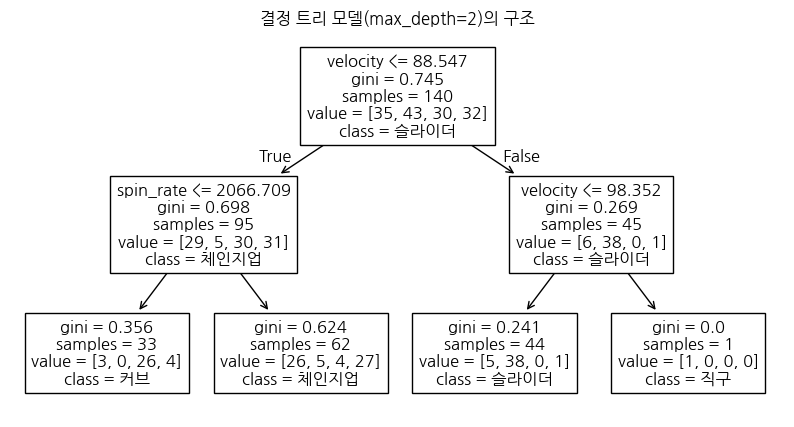

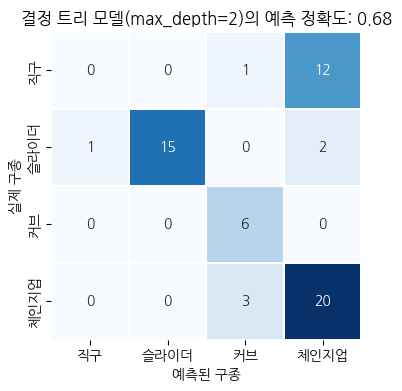

In [ ]:
K=2  # 트리의 최대 깊이 설정
# 분류 트리 모델 생성 및 학습
분류트리 = DecisionTreeClassifier(max_depth=K, random_state=42)
분류트리.fit(x_train, y_train)

# 예측 및 평가
y_pred = 분류트리.predict(x_test)
accuracy = accuracy_score(y_test, y_pred); print()

# 학습된 트리 모델 시각화하기
plt.figure(figsize=(10, 5))
plot_tree(분류트리, feature_names=X.columns, class_names=class_labels, filled=False)
plt.title(f'결정 트리 모델(max_depth={K})의 구조')
plt.show()

# 혼동 행렬 시각화 (이전과 동일)
cm = confusion_matrix(y_test, y_pred) # 혼동행렬 생성
acc =  accuracy_score(y_test, y_pred) # 분류정확도 계산
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True,linewidths=0.1, cmap='Blues',cbar=None,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('예측된 구종'); plt.ylabel('실제 구종')
plt.title(f'결정 트리 모델(max_depth={K})의 예측 정확도: {acc:.2f}')
plt.show()

max_depth=3 일 경우

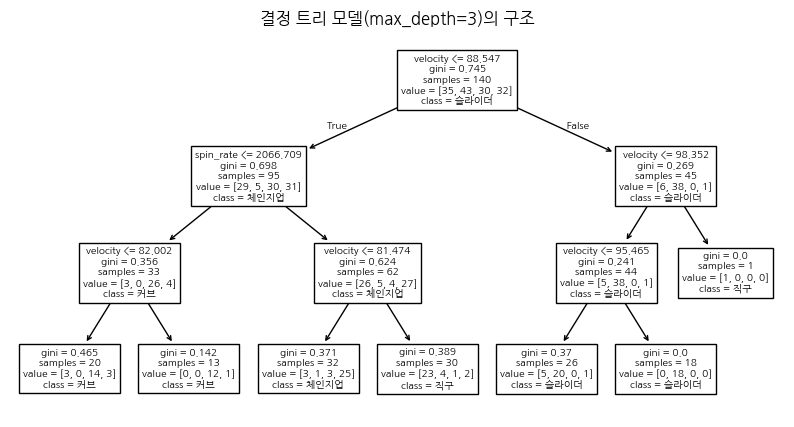

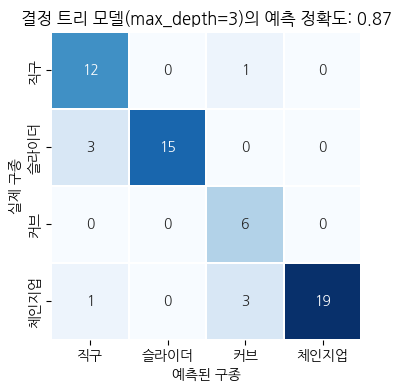

In [ ]:
K=3  # 트리의 최대 깊이 설정
# 분류 트리 모델 생성 및 학습
분류트리 = DecisionTreeClassifier(max_depth=K, random_state=42)
분류트리.fit(x_train, y_train)

# 예측 및 평가
y_pred = 분류트리.predict(x_test)
accuracy = accuracy_score(y_test, y_pred); print()

# 학습된 트리 모델 시각화하기
plt.figure(figsize=(10, 5))
plot_tree(분류트리, feature_names=X.columns, class_names=class_labels, filled=False)
plt.title(f'결정 트리 모델(max_depth={K})의 구조')
plt.show()

# 혼동 행렬 시각화 (이전과 동일)
cm = confusion_matrix(y_test, y_pred) # 혼동행렬 생성
acc =  accuracy_score(y_test, y_pred) # 분류정확도 계산
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True,linewidths=0.1, cmap='Blues',cbar=None,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('예측된 구종'); plt.ylabel('실제 구종')
plt.title(f'결정 트리 모델(max_depth={K})의 예측 정확도: {acc:.2f}')
plt.show()